# 2. Monitoreo temporal y detección de drift

## Resumen y propósito
Visualizamos distribuciones y estadísticos con ventanas móviles de 7 y 30 días. Comparamos el train inicial, validación, holdout etiquetado y test de competición **sin etiqueta**. Los scores V01 y su desempeño se revisan solo donde existen etiquetas.

## Método y supuestos
Los cortes son cronológicos. PSI y KS describen cambio de distribución; por sí solos no prueban un cambio en la relación entre variables y fraude. `TransactionDT` se usa para ordenar y dibujar el hueco entre archivos, pero se excluye del ranking de drift por variable.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

FINAL_ROOT = Path.cwd() if (Path.cwd() / 'v01_features.json').exists() else Path.cwd() / 'final'
__file__ = str(FINAL_ROOT / 'common.py')
V01_FEATURES = ['V258', 'C5', 'D1n', 'D3', 'C13', 'C1', 'C14', 'card1', 'D2n', 'card2', 'TransactionAmt', 'D15n', 'addr1', 'D2', 'D10n', 'C11', 'card6_label', 'P_emaildomain_label', 'C6', 'card5', 'D4', 'M4_freq', 'V257', 'D15', 'C2', 'C8', 'dist1', 'card3', 'card6_freq', 'C9', 'P_emaildomain_freq', 'D8', 'M4_label', 'M5_label', 'D1', 'D10', 'C10', 'M5_freq', 'id_02', 'C4', 'DT_hour', 'ProductCD_label', 'R_emaildomain_label', 'V189', 'V45', 'V243', 'D5', 'M6_freq', 'DeviceInfo_label', 'id_20', 'TransactionAmt_log1p', 'D11', 'id_01', 'C12', 'V87', 'DeviceInfo_freq', 'V78', 'V201', 'id_19', 'id_13', 'V140', 'ProductCD_freq', 'missing_D_count', 'V262', 'id_05', 'V38', 'M6_label', 'card4_label', 'dist2', 'V156', 'id_14', 'id_06', 'M3_label', 'missing_V_count', 'R_emaildomain_freq', 'V149', 'id_17', 'card4_freq', 'V94', 'D13', 'V37', 'id_18', 'DeviceType_freq', 'V74', 'D6', 'id_32', 'V58', 'D14', 'id_09', 'D9', 'D12', 'V86', 'addr2', 'C7', 'C3', 'V64', 'V170', 'id_03', 'D7', 'V44', 'V47', 'V217', 'missing_core_count', 'V52', 'V23', 'TransactionAmt_outlier_iqr', 'V79', 'M3_freq', 'V148', 'V157', 'M2_label', 'V33', 'V171', 'M9_label', 'M7_label', 'missing_id_count', 'V57', 'V219', 'V81', 'V39', 'M8_label', 'V154', 'V199', 'M9_freq', 'V232', 'V63', 'V34', 'V177', 'id_11', 'V228', 'V233', 'V230', 'V40', 'V158', 'V146', 'V231', 'id_04', 'V60', 'V155', 'V200', 'V51', 'V188', 'id_24', 'V190', 'DeviceType_label', 'V50', 'M8_freq', 'V85', 'V252', 'V73', 'M2_freq', 'id_21', 'V147', 'V197', 'V153', 'M7_freq', 'V16', 'V72', 'V84', 'V246', 'V43', 'V15', 'id_08', 'id_26', 'id_25', 'V244', 'id_07', 'V247', 'M1_freq', 'V93', 'V42', 'V71', 'V18', 'V242', 'V92', 'V32', 'id_10', 'V80', 'M1_label', 'V21', 'V17', 'V22', 'V31', 'has_identity', 'id_22']
RUN_FULL = (os.name == 'posix' and Path('/kaggle/working').exists()) or os.getenv('PTDIA_RUN_FULL') == '1'
print('Ejecución completa:', RUN_FULL)

Ejecución completa: False


### Implementación reproducible
Las funciones siguientes son código ejecutable del proyecto. Se agrupan por responsabilidad y se pueden ejecutar de arriba abajo sin archivos auxiliares.

In [2]:
"""Shared, deterministic IEEE-CIS helpers for the four final notebooks.

The notebook entry points call these functions. Nothing is fitted on future
rows: a preprocessing instance is created for each historical training window.
"""

from __future__ import annotations

import gc
import gzip
import json
import os
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, precision_score, recall_score

DAY = 86400
WEEK = 7 * DAY
SEED = 42
CAT_COLS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"] + [f"M{i}" for i in range(1, 10)]
MONITOR_COLS = ["TransactionAmt", "D1n", "D2n", "D10n", "D15n", "C9", "id_02", "id_20", "D11", "id_01"]


def paths(stage: str):
    here = Path(__file__).resolve().parent
    candidates = [
        Path("/kaggle/input/ieee-fraud-detection"),
        Path("/kaggle/input/competitions/ieee-fraud-detection"),
        here.parent / "ieee-fraud-detection",
    ]
    data = next((p for p in candidates if (p / "train_transaction.csv").exists()), None)
    if data is None:
        raise FileNotFoundError("IEEE-CIS competition input unavailable")
    output = Path("/kaggle/working") if os.name == "posix" and Path("/kaggle/working").exists() else here / "kaggle" / stage / "outputs"
    output.mkdir(parents=True, exist_ok=True)
    (output / "plots").mkdir(exist_ok=True)
    return data, output


def manifest(output: Path, **values):
    target = output / "run_summary.json"
    current = json.loads(target.read_text()) if target.exists() else {}
    current.update(values)
    target.write_text(json.dumps(current, indent=2, default=float), encoding="utf-8")


def save_plot(output: Path, name: str):
    plt.tight_layout()
    plt.savefig(output / "plots" / name, dpi=140, bbox_inches="tight")
    plt.close()


def load_data(data: Path, include_test: bool = False):
    def one(prefix: str):
        txn = pd.read_csv(data / f"{prefix}_transaction.csv", low_memory=False)
        identity = pd.read_csv(data / f"{prefix}_identity.csv", low_memory=False)
        # IEEE-CIS test identity uses id-01 style names, while train uses id_01.
        identity.rename(columns=lambda c: c.replace("id-", "id_") if c.startswith("id-") else c, inplace=True)
        if txn.TransactionID.duplicated().any() or identity.TransactionID.duplicated().any():
            raise ValueError("TransactionID must be unique in each source")
        out = txn.merge(identity, on="TransactionID", how="left", validate="one_to_one", indicator="_identity_join")
        del txn, identity
        gc.collect()
        out["has_identity_join"] = out["_identity_join"].eq("both").astype("int8")
        out.drop(columns="_identity_join", inplace=True)
        out.sort_values(["TransactionDT", "TransactionID"], inplace=True)
        out.reset_index(drop=True, inplace=True)
        return out

    train = one("train")
    test = one("test") if include_test else None
    return train, test


def split_bounds(df: pd.DataFrame):
    return float(df.TransactionDT.quantile(0.70)), float(df.TransactionDT.quantile(0.85))


def split_name(dt: pd.Series, bounds: tuple[float, float]):
    return np.where(dt <= bounds[0], "train", np.where(dt <= bounds[1], "valid", "holdout"))


def row_features(df: pd.DataFrame):
    """Only own-row information. Fitted statistics are added by WindowEncoder."""
    out = df.copy()
    day = (out.TransactionDT // DAY).astype("int16")
    out["DT_hour"] = ((out.TransactionDT // 3600) % 24).astype("int8")
    out["DT_day_index"] = day
    out["DT_week_index"] = (day // 7).astype("int16")
    out["has_identity"] = out["has_identity_join"].astype("int8")
    out["TransactionAmt_log1p"] = np.log1p(out.TransactionAmt.clip(lower=0)).astype("float32")
    for family in ("V", "D", "id_"):
        cols = [c for c in out if c.startswith(family) and (family == "id_" or c[len(family):].isdigit())]
        out[f"missing_{family.replace('_', '')}_count"] = out[cols].isna().sum(axis=1).astype("int16") if cols else 0
    core = [c for c in ["card2", "card3", "card5", "addr1", "addr2", "dist1", "dist2"] if c in out]
    out["missing_core_count"] = out[core].isna().sum(axis=1).astype("int8")
    for col in ["D1", "D2", "D10", "D15"]:
        out[f"{col}n"] = (out[col] - day).astype("float32")
    return out


def candidate_uid(df: pd.DataFrame):
    parts = df[["card1", "card2", "card3", "card5", "addr1", "addr2"]].astype("string").fillna("NA")
    parts = parts.copy()
    parts["D1_anchor"] = (df.D1 - df.TransactionDT // DAY).round(0).astype("string").fillna("NA")
    return pd.util.hash_pandas_object(parts, index=False).astype("uint64")

In [3]:
def feature_list():
    here = Path(__file__).resolve().parent
    for path in (here / "v01_features.json", here / "input" / "v01_features.json"):
        if path.exists():
            return json.loads(path.read_text(encoding="utf-8"))
    if "V01_FEATURES" in globals():
        return list(globals()["V01_FEATURES"])
    raise FileNotFoundError("v01_features.json is required")


@dataclass
class WindowEncoder:
    features: list[str]
    q_low: float = 0.0
    q_high: float = 0.0
    maps: dict | None = None
    freqs: dict | None = None

    def fit(self, train: pd.DataFrame):
        q1, q3 = train.TransactionAmt.quantile([.25, .75])
        self.q_low, self.q_high = float(q1 - 1.5 * (q3 - q1)), float(q3 + 1.5 * (q3 - q1))
        self.maps, self.freqs = {}, {}
        for col in CAT_COLS:
            if col not in train:
                continue
            s = train[col].astype("string").fillna("__MISSING__")
            self.maps[col] = {v: i for i, v in enumerate(s.unique())}
            self.freqs[col] = (s.value_counts(dropna=False) / len(s)).to_dict()
        return self

    def transform(self, rows: pd.DataFrame):
        cols = {}
        for name in self.features:
            if name == "TransactionAmt_outlier_iqr":
                cols[name] = ((rows.TransactionAmt < self.q_low) | (rows.TransactionAmt > self.q_high)).astype("float32")
            elif name.endswith("_label") and name[:-6] in self.maps:
                col = name[:-6]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.maps[col]).fillna(-1).astype("float32")
            elif name.endswith("_freq") and name[:-5] in self.freqs:
                col = name[:-5]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.freqs[col]).fillna(0).astype("float32")
            elif name in rows:
                cols[name] = pd.to_numeric(rows[name], errors="coerce").astype("float32")
            else:
                cols[name] = pd.Series(np.nan, index=rows.index, dtype="float32")
        return pd.DataFrame(cols, index=rows.index).replace([np.inf, -np.inf], np.nan)


def psi(reference, current, bins=10):
    a = np.asarray(reference, dtype=float)
    b = np.asarray(current, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 100 or len(b) < 100:
        return np.nan
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0 if np.isclose(np.mean(a), np.mean(b)) else np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.clip(np.histogram(a, edges)[0] / len(a), 1e-6, 1)
    pb = np.clip(np.histogram(b, edges)[0] / len(b), 1e-6, 1)
    return float(np.sum((pb - pa) * np.log(pb / pa)))


def safe_ap(y, pred):
    return float(average_precision_score(y, pred)) if len(y) and len(np.unique(y)) == 2 else np.nan


def evaluation_blocks(df: pd.DataFrame, bounds: tuple[float, float]):
    """Seven-day blocks clipped to each split; first valid week is label warm-up."""
    blocks = []
    for split, start, end in (("valid", bounds[0], bounds[1]), ("holdout", bounds[1], float(df.TransactionDT.max()) + 1)):
        index = 0
        t = start
        while t < end:
            u = min(t + WEEK, end)
            # First validation week warms up the seven-day label delay.
            if not (split == "valid" and index == 0):
                mask = (df.TransactionDT > t) & (df.TransactionDT <= u) if split == "valid" else (df.TransactionDT > t) & (df.TransactionDT < u)
                ix = df.index[mask].to_numpy()
                if len(ix):
                    blocks.append({"split": split, "block": index, "start": t, "end": u, "partial": u - t < WEEK, "indices": ix})
            t = u
            index += 1
    return blocks


def prediction_rows(df: pd.DataFrame, ix, uid_known, pred, model, strategy, window_days, block):
    return pd.DataFrame({
        "TransactionID": df.loc[ix, "TransactionID"].to_numpy(),
        "TransactionDT": df.loc[ix, "TransactionDT"].to_numpy(),
        "TransactionAmt": df.loc[ix, "TransactionAmt"].to_numpy(),
        "isFraud": df.loc[ix, "isFraud"].to_numpy(),
        "uid_known": uid_known,
        "score": np.asarray(pred),
        "model": model,
        "strategy": strategy,
        "window_days": window_days,
        "split": block["split"],
        "block": block["block"],
    })


def append_predictions(output: Path, rows: pd.DataFrame):
    path = output / "predictions.csv.gz"
    rows.to_csv(path, mode="at" if path.exists() else "wt", index=False, header=not path.exists(), compression="gzip")


def quick_cost(y, amount, score, review_fraction=.05, review_effectiveness=.8):
    """Offline same-capacity ranking proxy; operational queue is in policy notebook."""
    n = len(score)
    k = max(1, int(n * review_fraction))
    review = np.zeros(n, dtype=bool)
    review[np.argsort(score)[-k:]] = True
    loss = 4.41 * np.asarray(amount) * np.asarray(y)
    total = float(np.sum(np.where(review, 2 + (1 - review_effectiveness) * loss, loss)))
    return total / max(n, 1), float(recall_score(y, review, zero_division=0)), float(precision_score(y, review, zero_division=0))


def block_metrics(rows: pd.DataFrame, seconds=0.0, updated=False, device="none", psi_score=np.nan):
    y = rows.isFraud.to_numpy(dtype=int)
    p = rows.score.to_numpy(dtype=float)
    cost, recall, precision = quick_cost(y, rows.TransactionAmt, p)
    return {
        "model": rows.model.iloc[0], "strategy": rows.strategy.iloc[0], "window_days": rows.window_days.iloc[0],
        "split": rows.split.iloc[0], "block": int(rows.block.iloc[0]), "rows": len(rows),
        "fraud_rate": float(np.mean(y)), "pr_auc": safe_ap(y, p), "recall_at_5pct": recall,
        "precision_at_5pct": precision, "cost_per_txn_proxy": cost,
        "uid_known_pr_auc": safe_ap(y[rows.uid_known.to_numpy(dtype=bool)], p[rows.uid_known.to_numpy(dtype=bool)]),
        "uid_unknown_pr_auc": safe_ap(y[~rows.uid_known.to_numpy(dtype=bool)], p[~rows.uid_known.to_numpy(dtype=bool)]),
        "train_seconds": seconds, "updated": int(updated), "device": device, "psi_score": psi_score,
    }

In [4]:
def _v01_predictions():
    here = Path(__file__).resolve().parent
    candidates = [here / "v01_reference", here.parent / "03_outputs" / "v01_baseline_temporal"]
    candidates += list(Path("/kaggle/input").glob("**/baseline_valid_predictions.csv")) if Path("/kaggle/input").exists() else []
    for path in candidates:
        folder = path if path.is_dir() else path.parent
        a, b = folder / "baseline_valid_predictions.csv", folder / "baseline_holdout_predictions.csv"
        if a.exists() and b.exists():
            return pd.concat([pd.read_csv(a), pd.read_csv(b)], ignore_index=True)
    return None


def run_drift():
    data, out = paths("monitoreo")
    manifest(out, status="running", stage="load")
    train, test = load_data(data, include_test=True)
    bounds = split_bounds(train)
    train = row_features(train)
    test = row_features(test)
    train["origin"], test["origin"] = "train", "test"
    # Calendar-aligned one-week snapshots, with moving 7/30-day means.
    cols = ["TransactionDT", "origin", "has_identity", "TransactionAmt"] + [c for c in MONITOR_COLS if c not in ("TransactionAmt",) and c in train]
    both = pd.concat([train[cols], test[cols]], ignore_index=True)
    both["day"] = (both.TransactionDT // DAY).astype(int)
    daily = both.groupby(["origin", "day"], observed=True).agg(
        rows=("TransactionAmt", "size"), amt_median=("TransactionAmt", "median"),
        identity_rate=("has_identity", "mean"), C9_median=("C9", "median")
    ).reset_index().sort_values("day")
    for name in ("amt_median", "identity_rate", "C9_median"):
        for days in (7, 30):
            # Compute each origin separately to preserve the unobserved gap.
            daily[f"{name}_rolling_{days}d"] = np.nan
            for origin, part in daily.groupby("origin", sort=False):
                lookup = part.set_index("day")[name].sort_index()
                daily.loc[part.index, f"{name}_rolling_{days}d"] = [
                    lookup.loc[max(lookup.index.min(), d-days+1):d].mean() for d in part.day
                ]
    daily.to_csv(out / "sliding_daily.csv", index=False)
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    for ax, col, ylabel in zip(axes, ("amt_median", "identity_rate", "C9_median"), ("Monto mediano", "Cobertura identidad", "C9 mediana")):
        for days, style in ((7, "-"), (30, "--")):
            for origin, part in daily.groupby("origin", sort=False):
                ax.plot(part.day, part[f"{col}_rolling_{days}d"], style,
                        label=f"{days} dias" if origin == "train" else None)
        ax.axvline(train.TransactionDT.max() / DAY, color="gray", linestyle=":")
        ax.axvline(test.TransactionDT.min() / DAY, color="gray", linestyle=":")
        ax.set(ylabel=ylabel, title=f"{ylabel}: ventanas moviles")
        ax.legend()
    axes[-1].set_xlabel("Dia relativo; el espacio vacio es el hueco train/test")
    save_plot(out, "01_ventanas_7_30_dias.png")

    base = train.loc[train.TransactionDT <= bounds[0]]
    compare = []
    for origin, frame in (("valid", train.loc[(train.TransactionDT > bounds[0]) & (train.TransactionDT <= bounds[1])]),
                          ("holdout", train.loc[train.TransactionDT > bounds[1]]), ("test_unlabeled", test)):
        for col in MONITOR_COLS + ["has_identity"]:
            a = pd.to_numeric(base[col], errors="coerce").dropna().to_numpy()
            b = pd.to_numeric(frame[col], errors="coerce").dropna().to_numpy()
            if len(a) > 50000:
                a = np.random.default_rng(SEED).choice(a, 50000, replace=False)
            if len(b) > 50000:
                b = np.random.default_rng(SEED).choice(b, 50000, replace=False)
            compare.append({"period": origin, "feature": col, "ks": float(ks_2samp(a, b).statistic) if len(a) and len(b) else np.nan,
                            "psi": psi(a, b), "missing_reference": float(base[col].isna().mean()),
                            "missing_current": float(frame[col].isna().mean())})
    shift = pd.DataFrame(compare)
    shift.to_csv(out / "feature_shift.csv", index=False)
    heat = shift.pivot(index="feature", columns="period", values="ks")[["valid", "holdout", "test_unlabeled"]]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(heat.to_numpy(), cmap="YlOrRd", vmin=0, vmax=max(.2, np.nanmax(heat.to_numpy())))
    ax.set_xticks(range(len(heat.columns)), ["valid", "holdout", "test sin etiqueta"], rotation=15, ha="right")
    ax.set_yticks(range(len(heat.index)), heat.index)
    ax.set(title="KS frente al train inicial; se excluye tiempo absoluto")
    fig.colorbar(im, ax=ax, label="KS")
    save_plot(out, "02_ks_train_valid_holdout_test.png")

    v01 = _v01_predictions()
    if v01 is not None:
        v01["week"] = (v01.TransactionDT // WEEK).astype(int)
        scores = []
        first_week = int(v01.week.min())
        ref = v01.loc[v01.week == first_week, "pred"].to_numpy()
        for week, group in v01.groupby("week"):
            scores.append({"week": int(week), "rows": len(group), "psi_score": psi(ref, group.pred),
                           "pr_auc_matured": safe_ap(group.isFraud, group.pred), "fraud_rate": float(group.isFraud.mean())})
        scores = pd.DataFrame(scores)
        scores.to_csv(out / "v01_score_windows.csv", index=False)
        fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
        axes[0].plot(scores.week, scores.psi_score, marker="o")
        axes[0].axhline(.25, color="#e45756", linestyle="--", label="Alerta ilustrativa 0.25")
        axes[0].set(ylabel="PSI del score", title="Cambio de scores V01 frente a primera semana evaluada")
        axes[0].legend()
        axes[1].plot(scores.week, scores.pr_auc_matured, marker="o", label="PR-AUC tras llegar etiquetas")
        axes[1].plot(scores.week, scores.fraud_rate, marker="s", label="Prevalencia")
        axes[1].set(xlabel="Semana relativa", ylabel="Proporcion / PR-AUC")
        axes[1].legend()
        save_plot(out, "03_score_y_desempeno_v01.png")
    summary = {"shift_rows": len(shift), "score_windows": 0 if v01 is None else int(v01.week.nunique()),
               "test_has_target": "isFraud" in test, "score_source": "V01 historical predictions" if v01 is not None else "unavailable"}
    manifest(out, status="complete", stage="done", **summary)
    return out, summary

### Construir o cargar el monitoreo
Las salidas reproducibles incluyen estadísticas diarias móviles, comparación de variables y métricas de scores V01.

In [5]:
if RUN_FULL:
    output_dir, summary = run_drift()
else:
    output_dir = FINAL_ROOT / 'kaggle' / 'monitoreo' / 'outputs'
    summary_file = output_dir / 'run_summary.json'
    if not summary_file.exists():
        raise FileNotFoundError(f'Faltan outputs descargados: {summary_file}')
    summary = json.loads(summary_file.read_text(encoding='utf-8'))
print('Salidas:', output_dir)
display(pd.Series(summary, name='valor').to_frame())

Salidas: C:\Users\jeffr\GitHub\ptdia-proyecto1\final\kaggle\monitoreo\outputs


,valor
status,complete
stage,done
shift_rows,33
score_windows,10
test_has_target,False
score_source,V01 historical predictions


### Ventanas móviles
Las líneas de 7 días reaccionan más rápido; las de 30 días suavizan el ruido. El espacio sin observaciones entre train y test no representa drift medido.

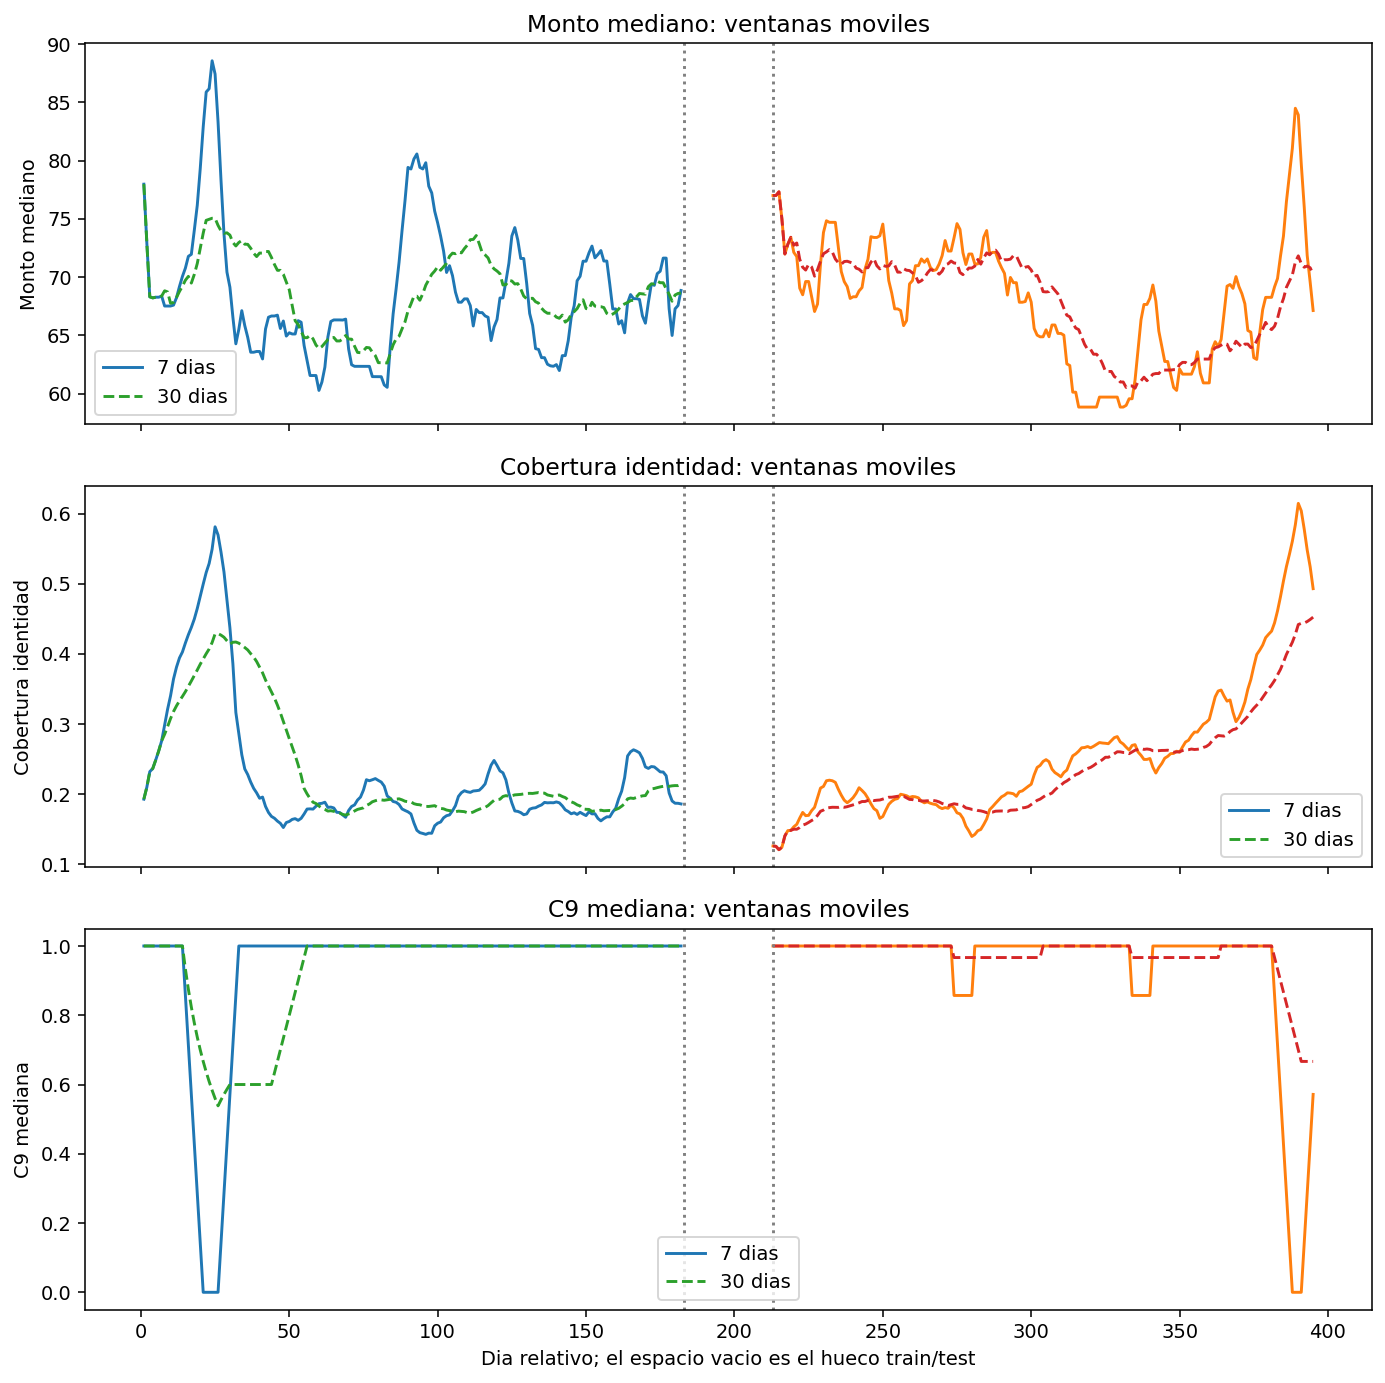

In [6]:
for name in ['01_ventanas_7_30_dias.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

### Shift de variables
La comparación usa la distribución inicial del train como referencia. Un KS alto motiva investigación; se revisa junto con faltantes y utilidad predictiva.

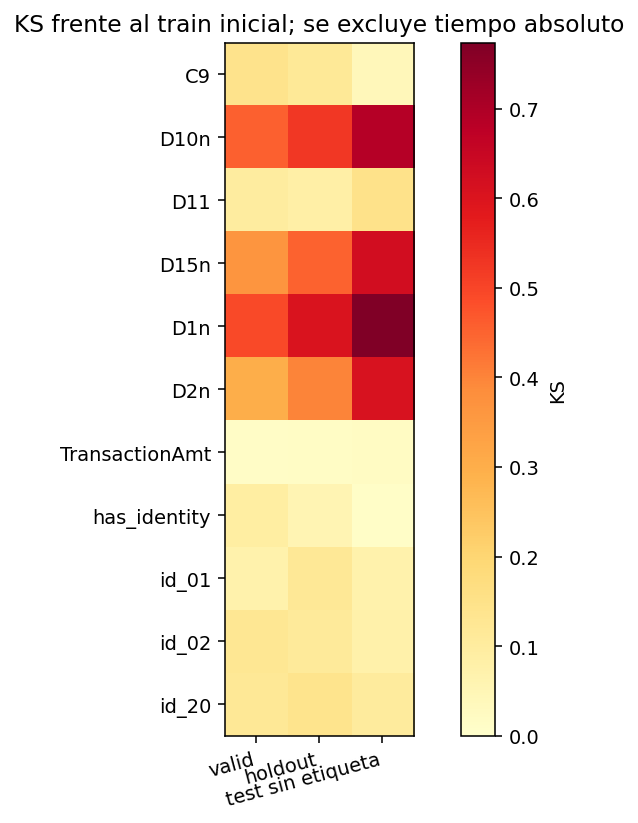

In [7]:
for name in ['02_ks_train_valid_holdout_test.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

In [8]:
display(pd.read_csv(output_dir / 'feature_shift.csv').sort_values('ks', ascending=False).head(18))

,period,feature,ks,psi,missing_reference,missing_current
23,test_unlabeled,D1n,0.773540,2.757315,0.000660,0.011903
25,test_unlabeled,D10n,0.688840,2.146639,0.148015,0.024759
26,test_unlabeled,D15n,0.622780,1.776524,0.165318,0.023819
24,test_unlabeled,D2n,0.608280,1.959249,0.499141,0.463338
12,holdout,D1n,0.604220,1.848603,0.000660,0.000463
14,holdout,D10n,0.524840,1.396318,0.148015,0.081981
1,valid,D1n,0.492320,1.444099,0.000660,0.010781
3,valid,D10n,0.453720,1.160885,0.148015,0.085504
15,holdout,D15n,0.452540,1.100634,0.165318,0.097651
13,holdout,D2n,0.401840,0.896461,0.499141,0.418385


### Scores y desempeño con etiquetas tardías
El score puede monitorearse sin etiquetas. En los diez cortes semanales etiquetados, el PSI frente a la primera semana permanece por debajo de 0.011 mientras PR-AUC oscila entre 0.473 y 0.732. Una alerta solo por PSI omitiría esa variación. PR-AUC y prevalencia requieren esperar las etiquetas.

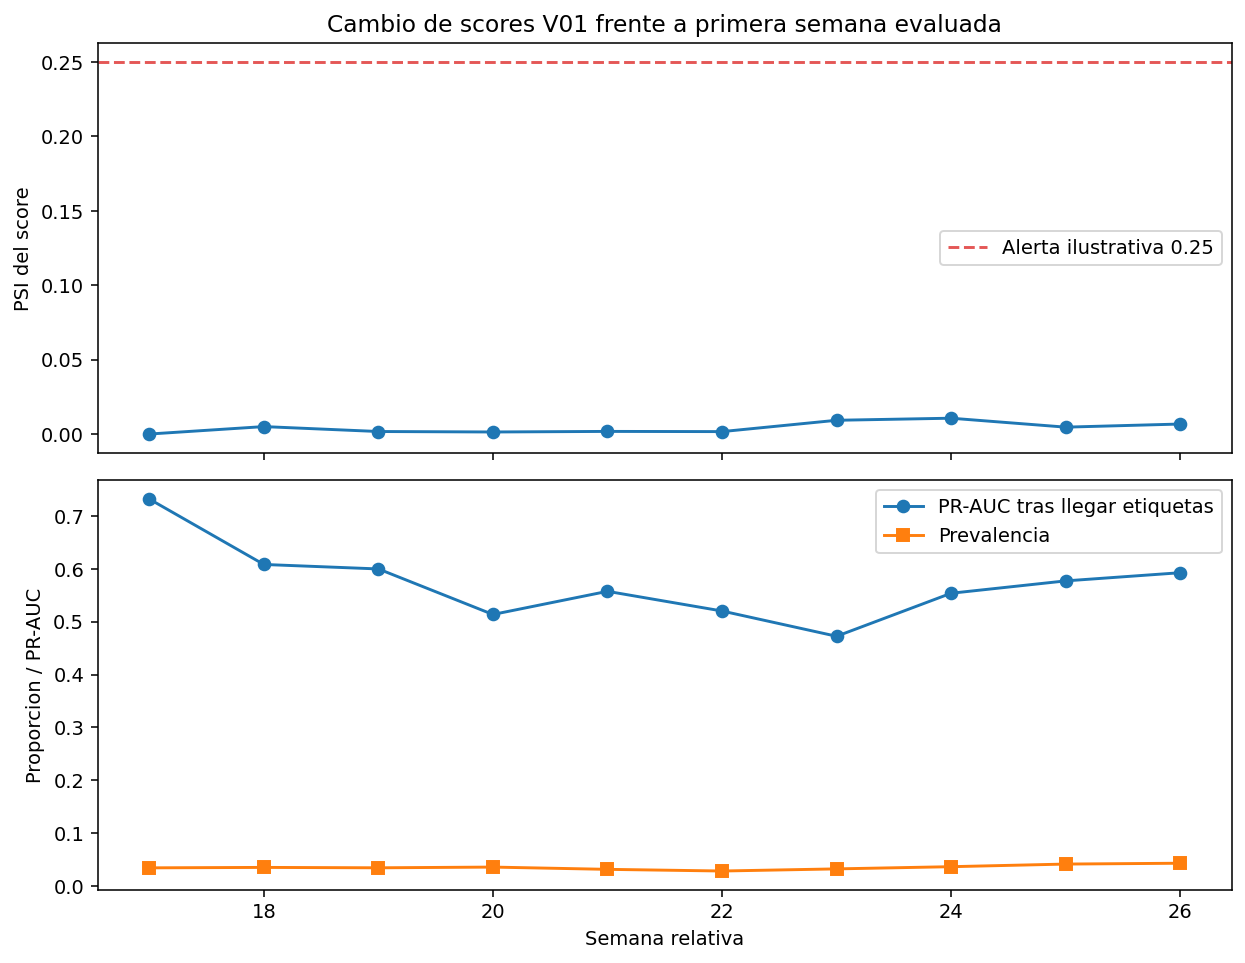

In [9]:
for name in ['03_score_y_desempeno_v01.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

## Conclusión y límite
Los límites de PSI/PR-AUC que se usarán como alertas son supuestos operativos fijados antes del holdout. La separación temporal train/test hace que KS sobre tiempo absoluto sea trivial, por lo que no se presenta como evidencia de concept drift. El test no aporta PR-AUC ni costo de negocio.